In [1]:
# Imports and Dataset Class Definition
import os
import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from PIL import Image

breed_map = {
    '01': 'Akhal-Teke', '02': 'Appaloosa', '03': 'Orlov Trotter',
    '04': 'Vladimir Heavy Draft', '05': 'Percheron', '06': 'Arabian', '07': 'Friesian'
}

class HorseBreedDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = [f for f in os.listdir(root_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
    def __len__(self):
        return len(self.image_files)
    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.root_dir, img_name)

        # 1. Load the image
        image = Image.open(img_path).convert('RGB')

        # 2. Extract label from filename (first two characters)
        # Example filename: 01_001.png -> we take "01"
        prefix = img_name.split('_')[0]

        # Convert prefix to an index starting from 0
        # '01' becomes 0, '02' becomes 1 ... etc.
        label = int(prefix) - 1

        if self.transform:
            image = self.transform(image)
        return image, label

# Setup transforms suitable for MaxViT model
# MaxViT usually requires images of size 224x224 and specific normalization
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [2]:
# Download Dataset
import kagglehub

# dataset = HorseBreedDataset(root_dir='/content/sample_data/Data', transform=data_transforms)
dataset = kagglehub.dataset_download("olgabelitskaya/horse-breeds")
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
print("Path to dataset files:", dataset)

# original_dataset = HorseBreedDataset(root_dir='/kaggle/input/horse-breeds', transform=data_transforms)
original_dataset = HorseBreedDataset(root_dir=dataset, transform=data_transforms)
from torch.utils.data import Subset

def create_balanced_subset(dataset, samples_per_class=20):
    indices = []
    class_counts = {i: 0 for i in range(7)}

    for idx, filename in enumerate(dataset.image_files):
        prefix = filename.split('_')[0]
        try:
            label = int(prefix) - 1
            if class_counts[label] < samples_per_class:
                indices.append(idx)
                class_counts[label] += 1
        except:
            continue

    return Subset(dataset, indices)

small_dataset = create_balanced_subset(original_dataset, samples_per_class=20)
small_dataloader = DataLoader(small_dataset, batch_size=16, shuffle=True)

print(f"Original Dataset Size: {len(original_dataset)}")
print(f"Small Dataset Size: {len(small_dataset)}")

counts = {i: 0 for i in range(7)}
original_data = small_dataset.dataset

for idx in small_dataset.indices:
    filename = original_data.image_files[idx]

    prefix = filename.split('_')[0]
    label = int(prefix) - 1

    counts[label] += 1

breed_names = [
    'Akhal-Teke', 'Appaloosa', 'Orlov Trotter',
    'Vladimir Heavy Draft', 'Percheron', 'Arabian', 'Friesian'
]

is_balanced = True
for label, count in counts.items():
    print(f"Class {label} ({breed_names[label]}): {count} images")
    if count != 20:
        is_balanced = False

Using Colab cache for faster access to the 'horse-breeds' dataset.
Path to dataset files: /kaggle/input/horse-breeds
Original Dataset Size: 670
Small Dataset Size: 140
Class 0 (Akhal-Teke): 20 images
Class 1 (Appaloosa): 20 images
Class 2 (Orlov Trotter): 20 images
Class 3 (Vladimir Heavy Draft): 20 images
Class 4 (Percheron): 20 images
Class 5 (Arabian): 20 images
Class 6 (Friesian): 20 images


In [3]:
# Model Setup (Frozen Weights)
import torchvision.models as models
import torch.nn as nn

def get_horse_model():
    # 1. Load MaxVit_tiny pre-trained model
    weights = models.MaxVit_T_Weights.DEFAULT
    model = models.maxvit_t(weights=weights)

    # 2. Freeze all layers (Freeze Weights)
    for param in model.parameters():
        param.requires_grad = False

    # 3. Modify the last classification layer (Classifier Head)
    # In MaxViT, the classifier layer is called "classifier" and consists of (AdaptiveAvgPool, Flatten, Linear...)
    # We want to change only the last linear layer to output 7 classes (number of horse breeds)
    # Get input features size of the current last layer
    # The last layer in MaxViT is usually item #5 inside the classifier block (linear layer)

    in_features = model.classifier[5].in_features
    model.classifier[5] = nn.Linear(in_features, 7)
    return model

# Create the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_horse_model().to(device)

# Verify that only the last layer is trainable
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"Training Layer: {name}")

Downloading: "https://download.pytorch.org/models/maxvit_t-bc5ab103.pth" to /root/.cache/torch/hub/checkpoints/maxvit_t-bc5ab103.pth


100%|██████████| 119M/119M [00:00<00:00, 155MB/s]


Training Layer: classifier.5.weight
Training Layer: classifier.5.bias


In [4]:
# Optimizer and One Epoch Train Function
import torch.optim as optim
# 1. Define Loss Function
criterion = nn.CrossEntropyLoss()
# 2. Define Optimizer
# Pass only parameters that require training (the last layer)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
# Simple Training Loop
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f"Epoch Loss: {total_loss / len(loader):.4f}, Accuracy: {100 * correct / total:.2f}%")

# Train one epoch to test
# train_one_epoch(model, dataloader, optimizer, criterion)

dataset_path = '/kaggle/input/horse-breeds' # This path is obtained from the output of cell EAvnDADaRh8j
dataset_corrected = HorseBreedDataset(root_dir=dataset_path, transform=data_transforms)
dataloader_corrected = DataLoader(dataset_corrected, batch_size=32, shuffle=True)

train_one_epoch(model, dataloader_corrected, optimizer, criterion)

Epoch Loss: 1.7278, Accuracy: 41.49%


In [5]:
# Full Training Loop (Frozen Model)
# 1. Training Settings
num_epochs = 20
best_acc = 0.0  # To save best accuracy reached
save_path = 'best_horse_maxvit.pth' # Path to save the model

# 2. Scheduler
# Multiplies learning rate by 0.1 every 7 epochs
# This helps improve accuracy when the model plateaus
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

print(f"Starting training for {num_epochs} epochs...")

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 10)

    # --- Training Mode ---
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in dataloader_corrected:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        # Calculate Statistics
        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Update Scheduler at the end of the epoch
    scheduler.step()

    # Calculate Averages for current epoch
    epoch_loss = total_loss / total
    epoch_acc = 100 * correct / total

    print(f"Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

    # --- Save Best Model ---
    if epoch_acc > best_acc:
        best_acc = epoch_acc
        torch.save(model.state_dict(), save_path)
        print(f"🚀 New Best Model Saved! (Accuracy: {best_acc:.2f}%)")

print(f"\nTraining Complete. Best Accuracy: {best_acc:.2f}%")

Starting training for 20 epochs...

Epoch 1/20
----------
Loss: 1.2960 | Accuracy: 68.21%
🚀 New Best Model Saved! (Accuracy: 68.21%)

Epoch 2/20
----------
Loss: 1.0209 | Accuracy: 75.67%
🚀 New Best Model Saved! (Accuracy: 75.67%)

Epoch 3/20
----------
Loss: 0.8628 | Accuracy: 78.96%
🚀 New Best Model Saved! (Accuracy: 78.96%)

Epoch 4/20
----------
Loss: 0.7563 | Accuracy: 82.24%
🚀 New Best Model Saved! (Accuracy: 82.24%)

Epoch 5/20
----------
Loss: 0.6928 | Accuracy: 84.33%
🚀 New Best Model Saved! (Accuracy: 84.33%)

Epoch 6/20
----------
Loss: 0.6282 | Accuracy: 85.67%
🚀 New Best Model Saved! (Accuracy: 85.67%)

Epoch 7/20
----------
Loss: 0.5937 | Accuracy: 86.72%
🚀 New Best Model Saved! (Accuracy: 86.72%)

Epoch 8/20
----------
Loss: 0.5613 | Accuracy: 87.91%
🚀 New Best Model Saved! (Accuracy: 87.91%)

Epoch 9/20
----------
Loss: 0.5584 | Accuracy: 86.57%

Epoch 10/20
----------
Loss: 0.5437 | Accuracy: 89.55%
🚀 New Best Model Saved! (Accuracy: 89.55%)

Epoch 11/20
----------
Los

In [6]:
# Fine-Tuning Setup and Training

# Ensure you import the Dataset class defined earlier
# from your_dataset_file import HorseBreedDataset

# 1. Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Data Setup
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset_ft = HorseBreedDataset(root_dir=dataset_path, transform=data_transforms)
dataloader_ft = DataLoader(dataset_ft, batch_size=32, shuffle=True)

# 3. Model Setup (Fine-Tuning Model)
print("Initializing MaxViT_T model...")
weights = models.MaxVit_T_Weights.DEFAULT
ft_model = models.maxvit_t(weights=weights)

# Modify last layer to fit 7 classes (Most Important Step)
# Extract input features of current last layer
in_features = ft_model.classifier[5].in_features
# Replace it with a new layer outputting 7 values
ft_model.classifier[5] = nn.Linear(in_features, 7)

# Move model to Device (GPU/CPU)
ft_model = ft_model.to(device)

# 4. Training Setup
num_epochs = 20
best_acc_fn = 0.0
save_path_fn = 'best_ft_horse_maxvit.pth'

# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer: Use low Learning Rate for full training
optimizer_ft = optim.Adam(ft_model.parameters(), lr=1e-4)

# Scheduler: To reduce learning rate every 7 epochs
scheduler_ft = optim.lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

# 5. Training Loop
print(f"Starting Fine-Tuning for ft_model on {device}...")

for epoch in range(num_epochs):
    ft_model.train() # Enable training mode
    total_loss = 0
    correct = 0
    total = 0

    # Ensure dataloader is defined previously
    for images, labels in dataloader_ft:
        images, labels = images.to(device), labels.to(device)

        optimizer_ft.zero_grad() # Zero gradients

        outputs = ft_model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer_ft.step()

        # Accumulate Statistics
        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Update Scheduler
    scheduler_ft.step()

    # Calculate Averages
    epoch_loss = total_loss / total
    epoch_acc = 100 * correct / total

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

    # Save Best Model
    if epoch_acc > best_acc_fn:
        best_acc_fn = epoch_acc
        torch.save(ft_model.state_dict(), save_path_fn)
        print(f"🚀 Saved Best ft_model (Acc: {best_acc_fn:.2f}%)")

print("Training Complete!")

Using device: cuda
Initializing MaxViT_T model...
Starting Fine-Tuning for ft_model on cuda...
Epoch 1/20 - Loss: 1.6231 | Accuracy: 49.85%
🚀 Saved Best ft_model (Acc: 49.85%)
Epoch 2/20 - Loss: 0.8606 | Accuracy: 82.09%
🚀 Saved Best ft_model (Acc: 82.09%)
Epoch 3/20 - Loss: 0.4298 | Accuracy: 92.99%
🚀 Saved Best ft_model (Acc: 92.99%)
Epoch 4/20 - Loss: 0.2129 | Accuracy: 97.31%
🚀 Saved Best ft_model (Acc: 97.31%)
Epoch 5/20 - Loss: 0.1224 | Accuracy: 98.51%
🚀 Saved Best ft_model (Acc: 98.51%)
Epoch 6/20 - Loss: 0.0696 | Accuracy: 99.70%
🚀 Saved Best ft_model (Acc: 99.70%)
Epoch 7/20 - Loss: 0.0456 | Accuracy: 99.70%
Epoch 8/20 - Loss: 0.0349 | Accuracy: 99.85%
🚀 Saved Best ft_model (Acc: 99.85%)
Epoch 9/20 - Loss: 0.0337 | Accuracy: 99.85%
Epoch 10/20 - Loss: 0.0315 | Accuracy: 100.00%
🚀 Saved Best ft_model (Acc: 100.00%)
Epoch 11/20 - Loss: 0.0271 | Accuracy: 100.00%
Epoch 12/20 - Loss: 0.0259 | Accuracy: 100.00%
Epoch 13/20 - Loss: 0.0288 | Accuracy: 99.85%
Epoch 14/20 - Loss: 0.02

In [7]:
print("\n--- Training model2 (Frozen) on Small Data ---")

# Correctly initialize small_dataset and small_dataloader
# small_data_path = "/content/sample_data/small_data"
# small_dataset_instance = HorseBreedDataset(root_dir=small_data, transform=data_transforms)
# small_dataloader = DataLoader(small_dataset_instance, batch_size=16, shuffle=True)

model2 = get_horse_model().to(device)
optimizer_m2 = optim.Adam(filter(lambda p: p.requires_grad, model2.parameters()), lr=0.001)
criterion = nn.CrossEntropyLoss()

num_epochs_small = 20

for epoch in range(num_epochs_small):
    model2.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in small_dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer_m2.zero_grad()
        outputs = model2(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_m2.step()

        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{num_epochs_small} - Acc: {epoch_acc:.2f}%")





--- Training model2 (Frozen) on Small Data ---
Epoch 1/20 - Acc: 17.86%
Epoch 2/20 - Acc: 49.29%
Epoch 3/20 - Acc: 70.00%
Epoch 4/20 - Acc: 73.57%
Epoch 5/20 - Acc: 81.43%
Epoch 6/20 - Acc: 77.86%
Epoch 7/20 - Acc: 84.29%
Epoch 8/20 - Acc: 84.29%
Epoch 9/20 - Acc: 85.00%
Epoch 10/20 - Acc: 86.43%
Epoch 11/20 - Acc: 90.00%
Epoch 12/20 - Acc: 91.43%
Epoch 13/20 - Acc: 91.43%
Epoch 14/20 - Acc: 87.14%
Epoch 15/20 - Acc: 91.43%
Epoch 16/20 - Acc: 91.43%
Epoch 17/20 - Acc: 92.86%
Epoch 18/20 - Acc: 91.43%
Epoch 19/20 - Acc: 93.57%
Epoch 20/20 - Acc: 95.00%


In [14]:
print("\n--- Training fn_model2 (Fine-Tuned) on Small Data ---")

weights = models.MaxVit_T_Weights.DEFAULT
fn_model2 = models.maxvit_t(weights=weights)
in_features = fn_model2.classifier[5].in_features
fn_model2.classifier[5] = nn.Linear(in_features, 7)
fn_model2 = fn_model2.to(device)

optimizer_fn2 = optim.Adam(fn_model2.parameters(), lr=1e-4)

for epoch in range(num_epochs_small):
    fn_model2.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in small_dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer_fn2.zero_grad()
        outputs = fn_model2(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_fn2.step()

        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{num_epochs_small} - Acc: {epoch_acc:.2f}%")


--- Training fn_model2 (Fine-Tuned) on Small Data ---
Epoch 1/20 - Acc: 25.71%
Epoch 2/20 - Acc: 72.14%
Epoch 3/20 - Acc: 93.57%
Epoch 4/20 - Acc: 94.29%
Epoch 5/20 - Acc: 95.71%
Epoch 6/20 - Acc: 99.29%
Epoch 7/20 - Acc: 99.29%
Epoch 8/20 - Acc: 100.00%
Epoch 9/20 - Acc: 100.00%
Epoch 10/20 - Acc: 100.00%
Epoch 11/20 - Acc: 100.00%
Epoch 12/20 - Acc: 100.00%
Epoch 13/20 - Acc: 100.00%
Epoch 14/20 - Acc: 100.00%
Epoch 15/20 - Acc: 100.00%
Epoch 16/20 - Acc: 100.00%
Epoch 17/20 - Acc: 100.00%
Epoch 18/20 - Acc: 100.00%
Epoch 19/20 - Acc: 100.00%
Epoch 20/20 - Acc: 100.00%


In [8]:
# Prediction Function
import requests
from PIL import Image
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 1. List of breed names in order (based on 01, 02... order)
class_names = [
    'Akhal-Teke',          # 0
    'Appaloosa',           # 1
    'Orlov Trotter',       # 2
    'Vladimir Heavy Draft',# 3
    'Percheron',           # 4
    'Arabian',             # 5
    'Friesian'             # 6
]

def predict_horse_breed(model, image_path_or_url, model_name="Model"):
    # Define Device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval() # Eval mode is critical to disable Dropout and Batchnorm

    headers = { 'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
    try:
        # Load Image
        if image_path_or_url.startswith('http'):
            response = requests.get(image_path_or_url, headers=headers, stream=True)
            response.raise_for_status() # Check for link errors (404 or 403)
            image = Image.open(response.raw).convert('RGB')
        else:
            image = Image.open(image_path_or_url).convert('RGB')

        # Display Image
        plt.imshow(image)
        plt.title(f"Input Image for {model_name}")
        plt.axis('off')
        plt.show()

        # Process and Predict
        # data_transforms defined in previous steps
        img_tensor = data_transforms(image).unsqueeze(0).to(device) # Add batch dimension (1, 3, 224, 224)

        with torch.no_grad():
            outputs = model(img_tensor)
            probabilities = F.softmax(outputs, dim=1) # Convert outputs to probabilities

            # Get highest probability
            confidence, predicted_idx = torch.max(probabilities, 1)

            predicted_breed = class_names[predicted_idx.item()]
            conf_score = confidence.item() * 100

            print(f"🔍 {model_name} Prediction:")
            print(f"   Breed: {predicted_breed}")
            print(f"   Confidence: {conf_score:.2f}%")

            # Show probabilities for other classes
            print("   Other Probabilities:")
            for i, prob in enumerate(probabilities[0]):
                if prob.item() > 0.01: # Print only probabilities > 1% for cleaner output
                    print(f"     - {class_names[i]}: {prob.item()*100:.2f}%")
            print("-" * 30)

    except Exception as e:
        print(f"❌ Error loading image: {e}")

--- Testing Frozen Model (model) ---


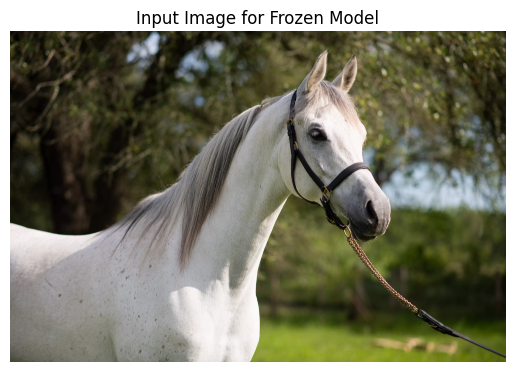

🔍 Frozen Model Prediction:
   Breed: Arabian
   Confidence: 31.57%
   Other Probabilities:
     - Akhal-Teke: 7.80%
     - Appaloosa: 14.41%
     - Orlov Trotter: 24.83%
     - Vladimir Heavy Draft: 7.41%
     - Percheron: 12.62%
     - Arabian: 31.57%
     - Friesian: 1.36%
------------------------------

--- Testing Fine-Tuned Model (fn_model) ---


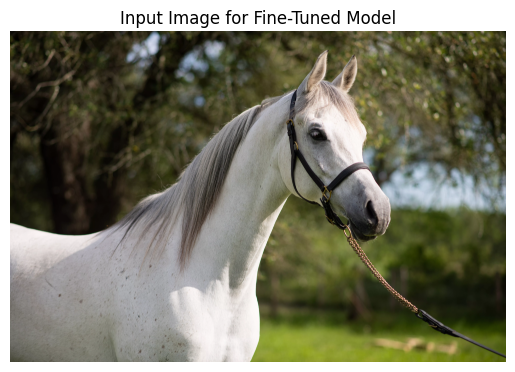

🔍 Fine-Tuned Model Prediction:
   Breed: Orlov Trotter
   Confidence: 73.69%
   Other Probabilities:
     - Akhal-Teke: 1.25%
     - Appaloosa: 2.44%
     - Orlov Trotter: 73.69%
     - Vladimir Heavy Draft: 2.55%
     - Percheron: 3.65%
     - Arabian: 15.94%
------------------------------


In [9]:
# Testing
# Put image URL here
url="https://cdn.ehorses.media/image/blur/searchresults/arabian-horses-gelding-4years-15-1-hh-grey-leisurehorses-endurancehorses-westernhorses-wassertruedingen_8711d819-06b8-4680-924e-84c31814b5e1.jpg"
url2 = "https://www.thesprucepets.com/thmb/iPgpcVkMuSPkl30JFZ1FvM7KOpA=/8256x0/filters:no_upscale():strip_icc():format(webp)/meet-the-arabian-horse-1886131-hero-64149239444241ff8e1255c2f2d5bd8b.jpg"


print("--- Testing Frozen Model (model) ---")
predict_horse_breed(model, url2, model_name="Frozen Model")

print("\n--- Testing Fine-Tuned Model (fn_model) ---")
# Ensure fn_model is trained
predict_horse_breed(ft_model, url2, model_name="Fine-Tuned Model")

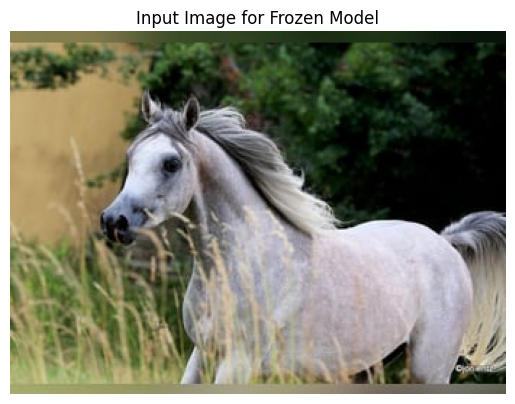

🔍 Frozen Model Prediction:
   Breed: Arabian
   Confidence: 38.34%
   Other Probabilities:
     - Akhal-Teke: 5.05%
     - Appaloosa: 7.65%
     - Orlov Trotter: 18.80%
     - Vladimir Heavy Draft: 1.53%
     - Percheron: 10.37%
     - Arabian: 38.34%
     - Friesian: 18.26%
------------------------------


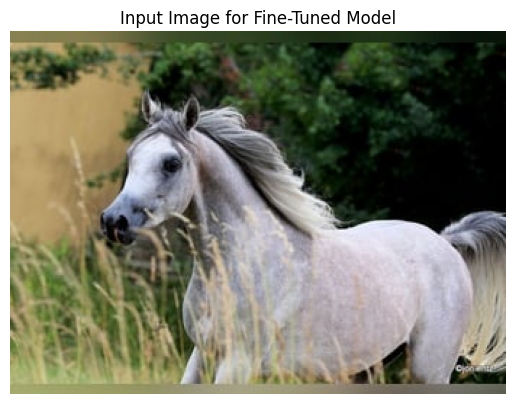

🔍 Fine-Tuned Model Prediction:
   Breed: Arabian
   Confidence: 96.44%
   Other Probabilities:
     - Orlov Trotter: 2.59%
     - Arabian: 96.44%
------------------------------


In [10]:
predict_horse_breed(model, url, model_name="Frozen Model")
predict_horse_breed(ft_model, url, model_name="Fine-Tuned Model")

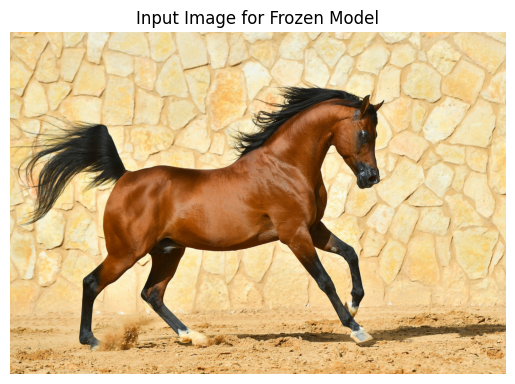

🔍 Frozen Model Prediction:
   Breed: Arabian
   Confidence: 40.50%
   Other Probabilities:
     - Akhal-Teke: 33.23%
     - Appaloosa: 2.89%
     - Orlov Trotter: 6.52%
     - Vladimir Heavy Draft: 13.34%
     - Percheron: 1.59%
     - Arabian: 40.50%
     - Friesian: 1.93%
------------------------------


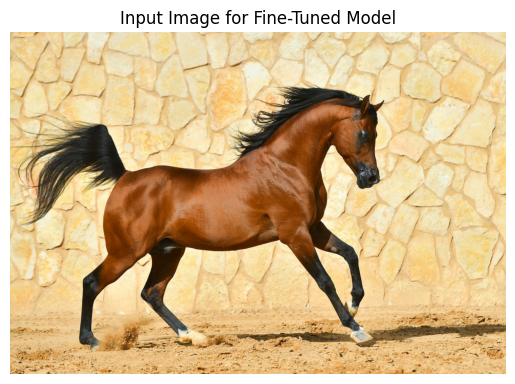

🔍 Fine-Tuned Model Prediction:
   Breed: Akhal-Teke
   Confidence: 65.24%
   Other Probabilities:
     - Akhal-Teke: 65.24%
     - Arabian: 33.33%
------------------------------


In [11]:
url3="https://cdn.globetrotting.co/20210515082633/shutterstock_1320363314-e1621033372325.jpg"
predict_horse_breed(model, url3, model_name="Frozen Model")
predict_horse_breed(ft_model, url3, model_name="Fine-Tuned Model")

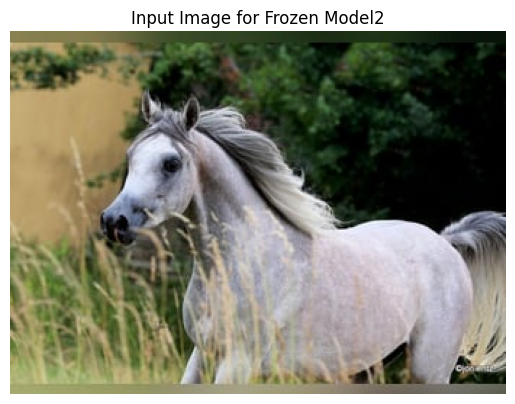

🔍 Frozen Model2 Prediction:
   Breed: Arabian
   Confidence: 46.68%
   Other Probabilities:
     - Akhal-Teke: 3.77%
     - Appaloosa: 6.67%
     - Orlov Trotter: 19.52%
     - Vladimir Heavy Draft: 3.54%
     - Percheron: 5.42%
     - Arabian: 46.68%
     - Friesian: 14.40%
------------------------------


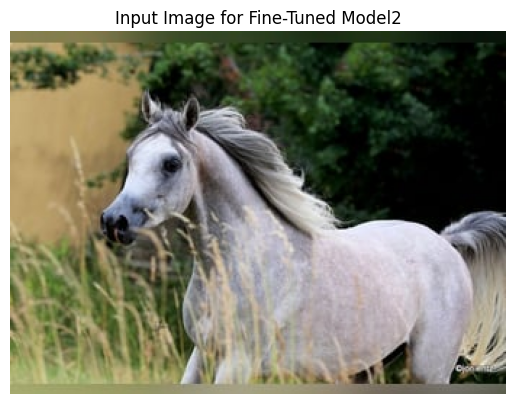

🔍 Fine-Tuned Model2 Prediction:
   Breed: Arabian
   Confidence: 97.55%
   Other Probabilities:
     - Orlov Trotter: 1.21%
     - Arabian: 97.55%
------------------------------


In [15]:
predict_horse_breed(model2, url, model_name="Frozen Model2")
predict_horse_breed(fn_model2, url, model_name="Fine-Tuned Model2")

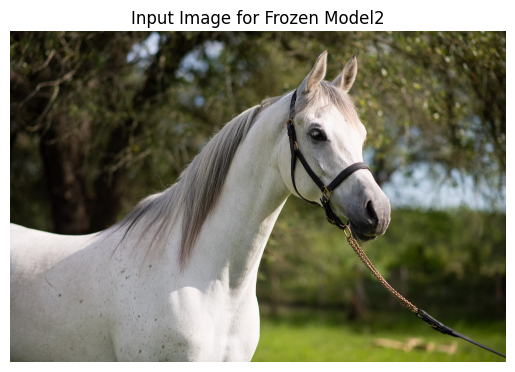

🔍 Frozen Model2 Prediction:
   Breed: Percheron
   Confidence: 30.24%
   Other Probabilities:
     - Akhal-Teke: 6.73%
     - Appaloosa: 22.79%
     - Orlov Trotter: 21.10%
     - Vladimir Heavy Draft: 9.56%
     - Percheron: 30.24%
     - Arabian: 8.61%
------------------------------


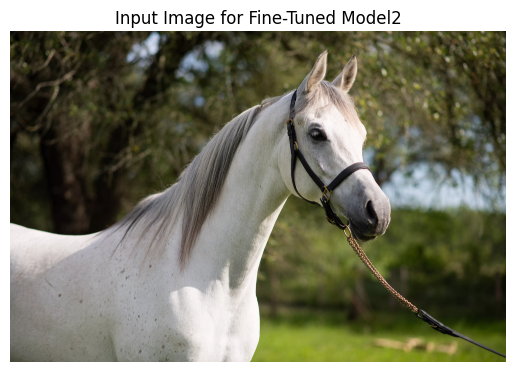

🔍 Fine-Tuned Model2 Prediction:
   Breed: Akhal-Teke
   Confidence: 37.98%
   Other Probabilities:
     - Akhal-Teke: 37.98%
     - Appaloosa: 6.54%
     - Orlov Trotter: 18.26%
     - Vladimir Heavy Draft: 1.57%
     - Percheron: 6.17%
     - Arabian: 28.54%
------------------------------


In [16]:
predict_horse_breed(model2, url2, model_name="Frozen Model2")
predict_horse_breed(fn_model2, url2, model_name="Fine-Tuned Model2")

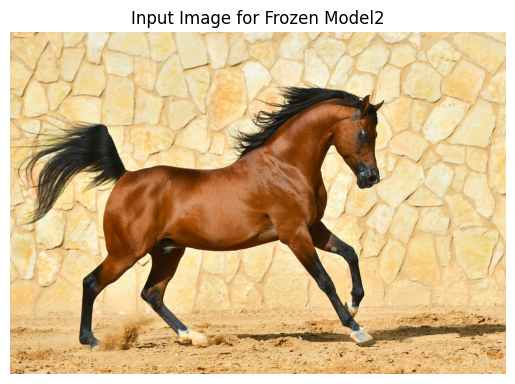

🔍 Frozen Model2 Prediction:
   Breed: Vladimir Heavy Draft
   Confidence: 36.06%
   Other Probabilities:
     - Akhal-Teke: 33.64%
     - Appaloosa: 4.33%
     - Orlov Trotter: 4.84%
     - Vladimir Heavy Draft: 36.06%
     - Percheron: 3.55%
     - Arabian: 15.61%
     - Friesian: 1.97%
------------------------------


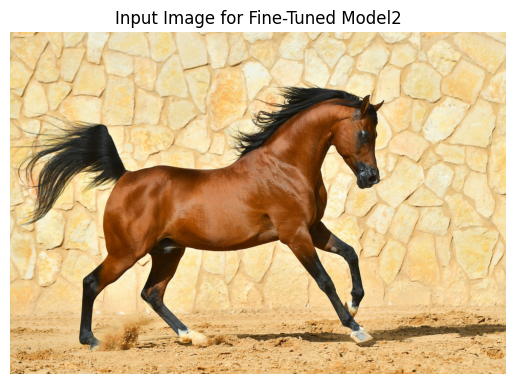

🔍 Fine-Tuned Model2 Prediction:
   Breed: Akhal-Teke
   Confidence: 62.55%
   Other Probabilities:
     - Akhal-Teke: 62.55%
     - Vladimir Heavy Draft: 15.45%
     - Arabian: 19.70%
------------------------------


In [17]:
predict_horse_breed(model2, url3, model_name="Frozen Model2")
predict_horse_breed(fn_model2, url3, model_name="Fine-Tuned Model2")